In [1]:
pip install pydicom matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.5 MB/s eta 0:00:00


Se encontraron 1 archivo(s) DICOM.

{'1.3.6.1.4.1.14519.5.2.1.240107720286503576160363009219423203106'}
========== RESUMEN DEL ESTUDIO ==========
Número de archivos cargados      : 1
Número de series (SeriesUID)     : 1
Número de estudios (StudyUID)    : 1
Número total de imágenes/frames  : 264

---------- METADATOS CLAVE ----------
Modality                : NM
Body Part Examined      : N/A
Manufacturer             : SIEMENS NM
Rows x Columns           : 128 x 128
Number of Frames         : 264
Bits Allocated           : 16
Bits Stored              : 16
Pixel Representation     : 0 (0 = sin signo, 1 = con signo)
Photometric Interpretation: MONOCHROME2
--------------------------------------------------------

---------- TAGS ESPECÍFICOS DE NM / SPECT ----------
EnergyWindowInformationSequence         : presente
RotationInformationSequence             : presente
DetectorInformationSequence             : presente
RadiopharmaceuticalInformationSequence  : presente
CollimatorType           

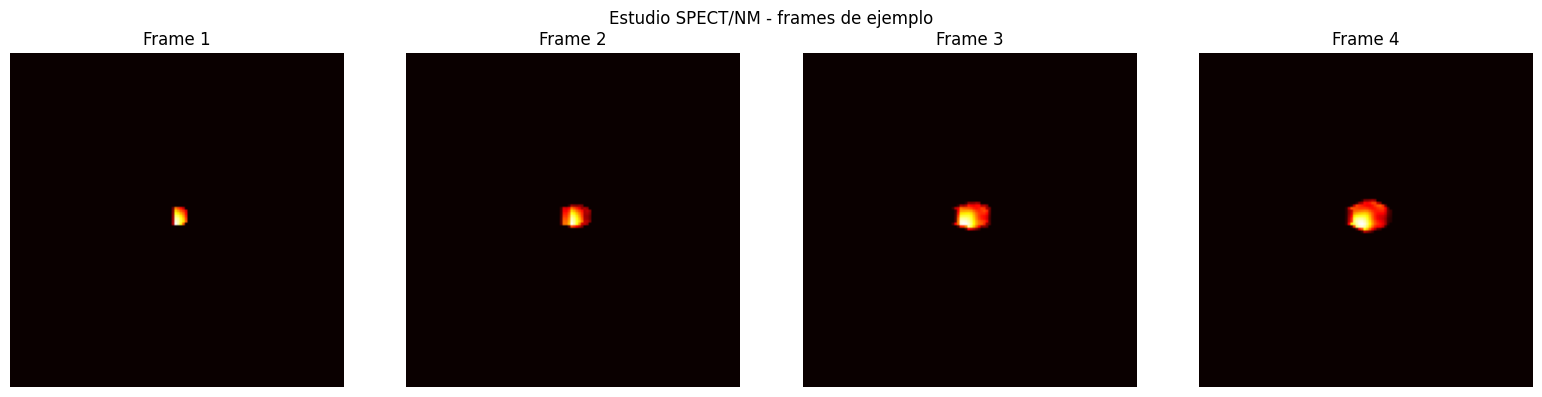

Imagen guardada como 'captura_estudio_spect.png' 
---------- TAMAÑO DEL ESTUDIO ----------
Tamaño total: 8455.6 KB (8.26 MB)
  nm-cardiac-varepop-apollo-instance.dcm: 8455.6 KB
-----------------------------------------

========== DATASET COMPLETO ==========
Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 206
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Nuclear Medicine Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.211298487579858787658467914719389800908
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002,0013) Implementation Version Name         SH: '0.5'
(0002,0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008,0005) Specific Character Set              CS

In [21]:
import os
import glob
import pydicom
import matplotlib.pyplot as plt
import numpy as np


# 1. Configuración: carpeta donde están el/los archivos .dcm del estudio

RUTA_ESTUDIO = "."  # cambiar si los datos .dcm están en otra carpeta

# Busca todos los archivos DICOM en la carpeta (algunos estudios NM vienen
# como un único archivo multi-frame; otros como varias imágenes/series)
archivos_dicom = sorted(
    glob.glob(os.path.join(RUTA_ESTUDIO, "*.dcm"))
    + glob.glob(os.path.join(RUTA_ESTUDIO, "*.DCM"))
)

if not archivos_dicom:
    raise FileNotFoundError(
        f"No se encontraron archivos .dcm en '{RUTA_ESTUDIO}'. "
    )

print(f"Se encontraron {len(archivos_dicom)} archivo(s) DICOM.\n")

# 2. Cargar todos los datasets y agrupar por Series/Study

datasets = []
for ruta in archivos_dicom:
    ds = pydicom.dcmread(ruta)
    datasets.append((ruta, ds))

series_unicas = {ds.get("SeriesInstanceUID", "N/A") for _, ds in datasets}
print(series_unicas)
estudios_unicos = {ds.get("StudyInstanceUID", "N/A") for _, ds in datasets}

# Un archivo NM suele contener múltiples "frames" (cortes/instantes) dentro
# de sí mismo, así que también se cuenta NumberOfFrames por archivo.

total_frames = 0
for _, ds in datasets:
    n_frames = int(getattr(ds, "NumberOfFrames", 1))
    total_frames += n_frames

print("========== RESUMEN DEL ESTUDIO ==========")
print(f"Número de archivos cargados      : {len(datasets)}")
print(f"Número de series (SeriesUID)     : {len(series_unicas)}")
print(f"Número de estudios (StudyUID)    : {len(estudios_unicos)}")
print(f"Número total de imágenes/frames  : {total_frames}")
print("==========================================\n")


# 3. Información general y tipo de dato de los píxeles (primer archivo)

_, ds0 = datasets[0]

print("---------- METADATOS CLAVE ----------")
print(f"Modality                : {ds0.get('Modality', 'N/A')}")
print(f"Body Part Examined      : {ds0.get('BodyPartExamined', 'N/A')}")
print(f"Manufacturer             : {ds0.get('Manufacturer', 'N/A')}")
print(f"Rows x Columns           : {ds0.get('Rows', 'N/A')} x {ds0.get('Columns', 'N/A')}")
print(f"Number of Frames         : {ds0.get('NumberOfFrames', 1)}")
print(f"Bits Allocated           : {ds0.get('BitsAllocated', 'N/A')}")
print(f"Bits Stored              : {ds0.get('BitsStored', 'N/A')}")
print(f"Pixel Representation     : {ds0.get('PixelRepresentation', 'N/A')} "
      "(0 = sin signo, 1 = con signo)")
print(f"Photometric Interpretation: {ds0.get('PhotometricInterpretation', 'N/A')}")
print("--------------------------------------------------------\n")

# 4. Tags específicos de Medicina Nuclear / SPECT


print("---------- TAGS ESPECÍFICOS DE NM / SPECT ----------")
tags_nm = [
    "EnergyWindowInformationSequence",
    "RotationInformationSequence",
    "DetectorInformationSequence",
    "RadiopharmaceuticalInformationSequence",
    "CollimatorType",
    "GantryDetectorTilt",
    "TypeOfDetectorMotion",
]
for tag in tags_nm:
    valor = ds0.get(tag, None)
    print(f"{tag:40s}: {'presente' if valor is not None else 'no presente en este archivo'}")
print("-----------------------------------------------------\n")


# 5. Mostrar la(s) imagen(es) con matplotlib

pixel_array = ds0.pixel_array  # forma: (frames, rows, cols) o (rows, cols)

if pixel_array.ndim == 3:
    n_frames_mostrar = min(4, pixel_array.shape[0])  # muestra hasta 4 frames
    fig, axs = plt.subplots(1, n_frames_mostrar, figsize=(4 * n_frames_mostrar, 4))
    if n_frames_mostrar == 1:
        axs = [axs]
    for i in range(n_frames_mostrar):
        axs[i].imshow(pixel_array[i], cmap="hot")  # 'hot' es típico para NM
        axs[i].set_title(f"Frame {i+1}")
        axs[i].axis("off")
    plt.suptitle("Estudio SPECT/NM - frames de ejemplo")
else:
    plt.figure(figsize=(6, 6))
    plt.imshow(pixel_array, cmap="hot")
    plt.title("Estudio SPECT/NM")
    plt.axis("off")

plt.tight_layout()
plt.savefig("captura_estudio_spect.png", dpi=150)
plt.show()
print("Imagen guardada como 'captura_estudio_spect.png' ")


# 6. Tamaño del estudio en disco

tamanos = [os.path.getsize(ruta) for ruta, _ in datasets]
print("---------- TAMAÑO DEL ESTUDIO ----------")
print(f"Tamaño total: {sum(tamanos) / 1024:.1f} KB "
      f"({sum(tamanos) / (1024 * 1024):.2f} MB)")
for ruta, t in zip(archivos_dicom, tamanos):
    print(f"  {os.path.basename(ruta)}: {t / 1024:.1f} KB")
print("-----------------------------------------\n")

# 7. Imprimir el dataset completo
print("========== DATASET COMPLETO ==========")
print(ds0)

In [20]:
print("Number of Frames        :", ds0.get("NumberOfFrames", "N/A"))
print("Number of Slices        :", ds0.get(0x00540081, "N/A"))       # (0054,0081) NM/PET
print("Number of Time Slots    :", ds0.get(0x00540071, "N/A"))       # (0054,0071) gated
print("Number of Rotations     :", ds0.get(0x00540053, "N/A"))       # (0054,0053) SPECT
print("Rows x Columns          :", ds0.Rows, "x", ds0.Columns)
print("Series Description      :", ds0.get("SeriesDescription", "N/A"))
print("Image Orientation Patient:", ds0.get("ImageOrientationPatient", "N/A"))
print("Protocol Name      :", ds0.get("ProtocolName", "N/A"))
print("Patient Orientation:", ds0.get("PatientOrientation", "N/A"))
print("View Position      :", ds0.get("ViewPosition", "N/A"))
print("Body Part Examined   :", ds0.get("BodyPartExamined", "N/A"))
print("ImageType        :", ds0.get("ImageType", "N/A"))


Number of Frames        : 264
Number of Slices        : (0054,0081) Number of Slices                    US: 33
Number of Time Slots    : (0054,0071) Number of Time Slots                US: 8
Number of Rotations     : N/A
Rows x Columns          : 128 x 128
Series Description      : Stress IQ-Gated [Recon]
Image Orientation Patient: N/A
Protocol Name      : 5.0.479385699@
Patient Orientation: N/A
View Position      : N/A
Body Part Examined   : N/A
ImageType        : ['ORIGINAL', 'PRIMARY', 'RECON GATED TOMO', 'EMISSION']


In [23]:
# Tamaño total del estudio y por imagen/frame (una sola serie)
tamano_archivo = os.path.getsize(archivos_dicom[0])
n_frames = int(getattr(ds0, "NumberOfFrames", 1))
tamano_pixeles = ds0.pixel_array.nbytes

print(f"Tamaño total del archivo/serie : {tamano_archivo / 1024:.1f} KB")
print(f"Número de frames               : {n_frames}")
print(f"Peso aprox. por frame (c/header): {tamano_archivo / n_frames / 1024:.2f} KB")
print(f"Peso por frame (solo píxeles)   : {tamano_pixeles / n_frames / 1024:.2f} KB")

Tamaño total del archivo/serie : 8455.6 KB
Número de frames               : 264
Peso aprox. por frame (c/header): 32.03 KB
Peso por frame (solo píxeles)   : 32.00 KB
